In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_lfw_people
from tensorflow.keras.datasets import mnist

LOAD MNIST

In [15]:
# Load MNIST
(X_train, y_train), (_, _) = mnist.load_data()

# Reduce size for fast execution
X_train = X_train[:10000]
y_train = y_train[:10000]

# Flatten + normalize
X_digits = X_train.reshape(10000, -1) / 255.0
y_digits = y_train

print("MNIST shape:", X_digits.shape)

MNIST shape: (10000, 784)


LOAD FACE DATASET

In [16]:
faces = fetch_lfw_people(min_faces_per_person=50, resize=0.4)

X_faces = faces.data / 255.0
y_faces = faces.target
h, w = faces.images.shape[1:3]

print("Faces shape:", X_faces.shape)

Faces shape: (1560, 1850)


RAW VISUALIZATION OF YOUR DATA



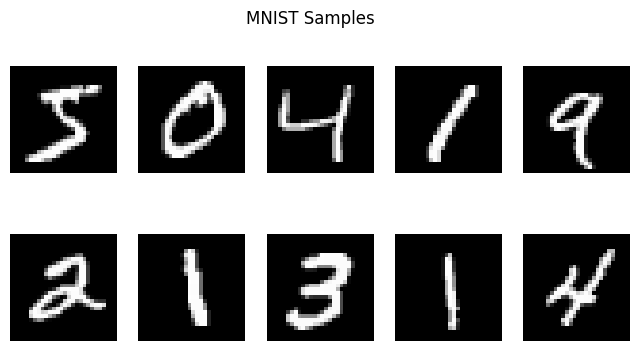

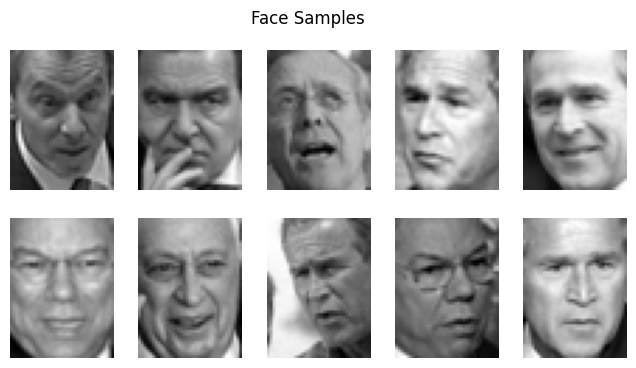

In [17]:
# MNIST samples
fig, axes = plt.subplots(2, 5, figsize=(8,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.axis('off')
plt.suptitle("MNIST Samples")
plt.show()

# Faces samples
fig, axes = plt.subplots(2, 5, figsize=(8,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(faces.images[i], cmap='gray')
    ax.axis('off')
plt.suptitle("Face Samples")
plt.show()

Apply PCA

In [18]:

# MNIST PCA
pca_digits = PCA(n_components=50)
X_digits_pca = pca_digits.fit_transform(X_digits)

# Faces PCA
pca_faces = PCA(n_components=100)
X_faces_pca = pca_faces.fit_transform(X_faces)

Explained Variance

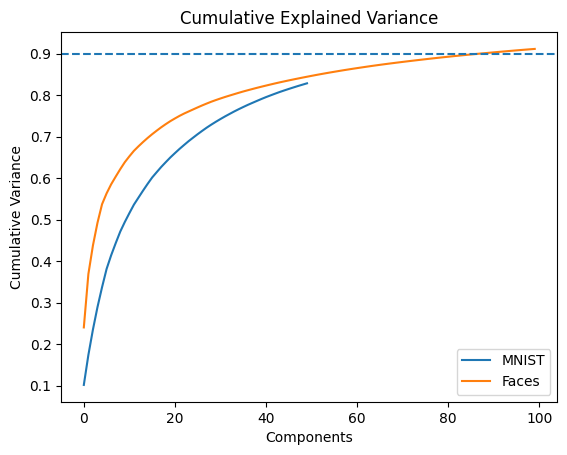

In [19]:
plt.plot(np.cumsum(pca_digits.explained_variance_ratio_), label="MNIST")
plt.plot(np.cumsum(pca_faces.explained_variance_ratio_), label="Faces")

plt.axhline(y=0.9, linestyle='--')

plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.legend()
plt.title("Cumulative Explained Variance")
plt.show()

2D Visualization (CLUSTERS)

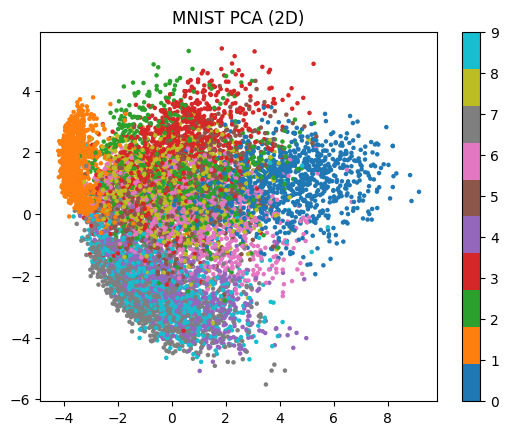

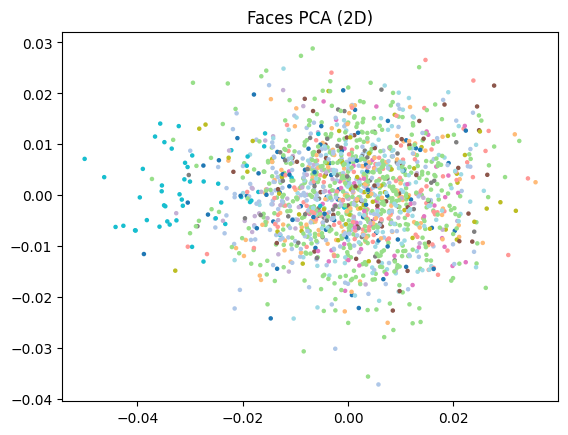

In [20]:
pca2 = PCA(n_components=2)

# MNIST
X_d2 = pca2.fit_transform(X_digits)
plt.scatter(X_d2[:,0], X_d2[:,1], c=y_digits, cmap='tab10', s=5)
plt.title("MNIST PCA (2D)")
plt.colorbar()
plt.show()

# Faces
X_f2 = pca2.fit_transform(X_faces)
plt.scatter(X_f2[:,0], X_f2[:,1], c=y_faces, cmap='tab20', s=5)
plt.title("Faces PCA (2D)")
plt.show()

RECONSTRUCTION


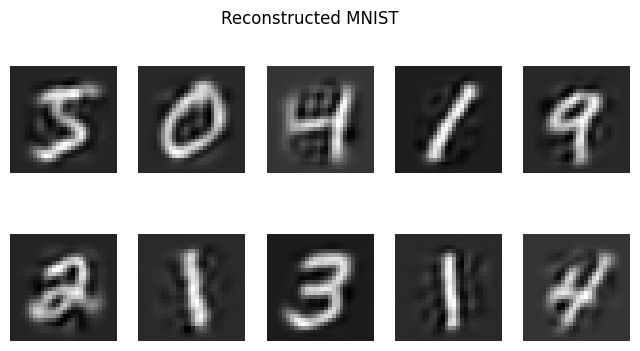

In [21]:
# MNIST reconstruction
X_digits_rec = pca_digits.inverse_transform(X_digits_pca)

fig, axes = plt.subplots(2, 5, figsize=(8,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_digits_rec[i].reshape(28,28), cmap='gray')
    ax.axis('off')
plt.suptitle("Reconstructed MNIST")
plt.show()

FACES RECONSTRUCTION


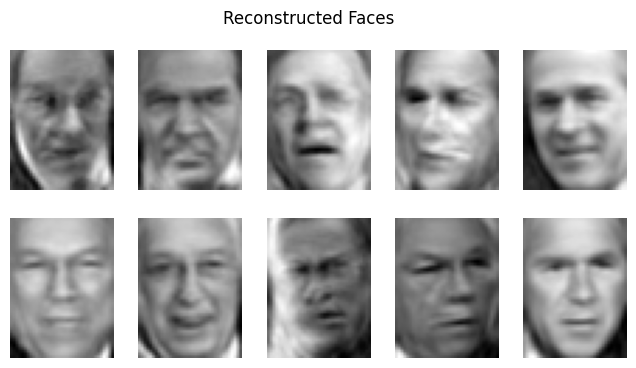

In [22]:
# Faces reconstruction
X_faces_rec = pca_faces.inverse_transform(X_faces_pca)

fig, axes = plt.subplots(2, 5, figsize=(8,4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_faces_rec[i].reshape(h, w), cmap='gray')
    ax.axis('off')
plt.suptitle("Reconstructed Faces")
plt.show()

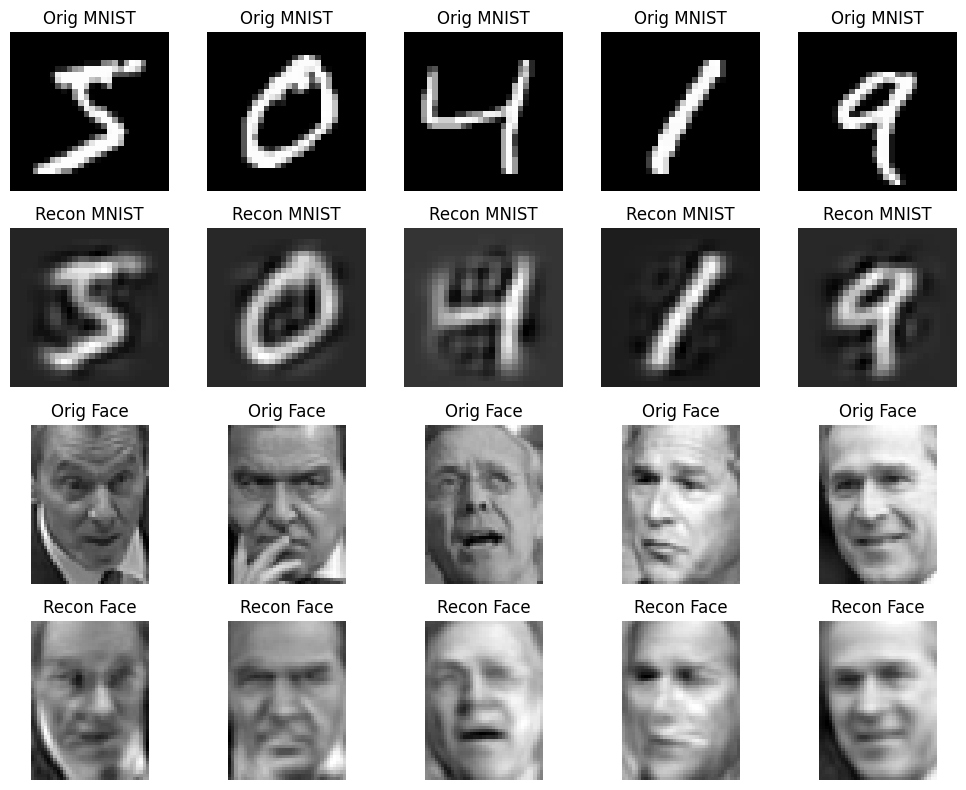

In [23]:
fig, axes = plt.subplots(4, 5, figsize=(10,8))

# MNIST Original
for i in range(5):
    axes[0, i].imshow(X_digits[i].reshape(28,28), cmap='gray')
    axes[0, i].set_title("Orig MNIST")
    axes[0, i].axis('off')

# MNIST Reconstructed
for i in range(5):
    axes[1, i].imshow(X_digits_rec[i].reshape(28,28), cmap='gray')
    axes[1, i].set_title("Recon MNIST")
    axes[1, i].axis('off')

# Faces Original
for i in range(5):
    axes[2, i].imshow(X_faces[i].reshape(h,w), cmap='gray')
    axes[2, i].set_title("Orig Face")
    axes[2, i].axis('off')

# Faces Reconstructed
for i in range(5):
    axes[3, i].imshow(X_faces_rec[i].reshape(h,w), cmap='gray')
    axes[3, i].set_title("Recon Face")
    axes[3, i].axis('off')

plt.tight_layout()
plt.show()

IMPORT MODEL


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

MNIST CLASSIFICATION

In [25]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)

TRAIN WITHOUT PCA

In [26]:
model = SVC()

model.fit(X_train_d, y_train_d)
y_pred = model.predict(X_test_d)

acc_no_pca = accuracy_score(y_test_d, y_pred)
print("Accuracy without PCA:", acc_no_pca)

Accuracy without PCA: 0.962


TRAIN WITHOUT PCA

In [27]:
# Apply PCA
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train_d)
X_test_pca = pca.transform(X_test_d)

# Train model
model_pca = SVC()
model_pca.fit(X_train_pca, y_train_d)

y_pred_pca = model_pca.predict(X_test_pca)

acc_pca = accuracy_score(y_test_d, y_pred_pca)
print("Accuracy with PCA:", acc_pca)

Accuracy with PCA: 0.971


FACES CLASSIFICATION

In [28]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_faces, y_faces, test_size=0.2, random_state=42
)

WITHOUT PCA

In [29]:
model_f = SVC()

model_f.fit(X_train_f, y_train_f)
y_pred_f = model_f.predict(X_test_f)

acc_faces_no_pca = accuracy_score(y_test_f, y_pred_f)
print("Faces Accuracy without PCA:", acc_faces_no_pca)

Faces Accuracy without PCA: 0.6987179487179487


WITH PCA


In [30]:
pca_f = PCA(n_components=100)
X_train_fpca = pca_f.fit_transform(X_train_f)
X_test_fpca = pca_f.transform(X_test_f)

model_fpca = SVC()
model_fpca.fit(X_train_fpca, y_train_f)

y_pred_fpca = model_fpca.predict(X_test_fpca)

acc_faces_pca = accuracy_score(y_test_f, y_pred_fpca)
print("Faces Accuracy with PCA:", acc_faces_pca)

Faces Accuracy with PCA: 0.6955128205128205


In [31]:
print("\n--- FINAL COMPARISON ---")
print(f"MNIST: Without PCA = {acc_no_pca:.4f}, With PCA = {acc_pca:.4f}")
print(f"FACES: Without PCA = {acc_faces_no_pca:.4f}, With PCA = {acc_faces_pca:.4f}")


--- FINAL COMPARISON ---
MNIST: Without PCA = 0.9620, With PCA = 0.9710
FACES: Without PCA = 0.6987, With PCA = 0.6955


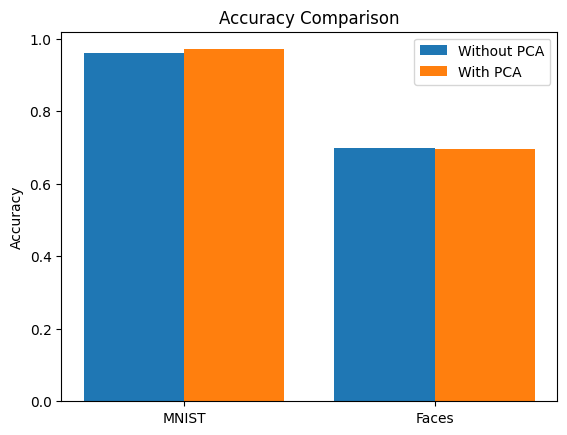

In [32]:
labels = ['MNIST', 'Faces']
without_pca = [acc_no_pca, acc_faces_no_pca]
with_pca = [acc_pca, acc_faces_pca]

x = np.arange(len(labels))

plt.bar(x - 0.2, without_pca, 0.4, label='Without PCA')
plt.bar(x + 0.2, with_pca, 0.4, label='With PCA')

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

PCA reduced training timing


In [34]:
import time

start = time.time()
model.fit(X_train_d, y_train_d)
print("Without PCA Time:", time.time() - start)

start = time.time()
model_pca.fit(X_train_pca, y_train_d)
print("With PCA Time:", time.time() - start)

Without PCA Time: 9.942188739776611
With PCA Time: 1.7691843509674072


In [35]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(X_digits, X_digits_rec)
print("Reconstruction Error:", mse)

Reconstruction Error: 0.01155557630987507


COMPARING THIS WITH t-SNE

In [36]:
from sklearn.manifold import TSNE

In [37]:
# MNIST (take subset)
X_digits_small = X_digits[:2000]
y_digits_small = y_digits[:2000]

# Faces (already small usually, but still limit)
X_faces_small = X_faces[:1000]
y_faces_small = y_faces[:1000]

APPLYING ON MNIST DATASET

In [38]:
tsne_digits = TSNE(n_components=2, random_state=42)
X_digits_tsne = tsne_digits.fit_transform(X_digits_small)

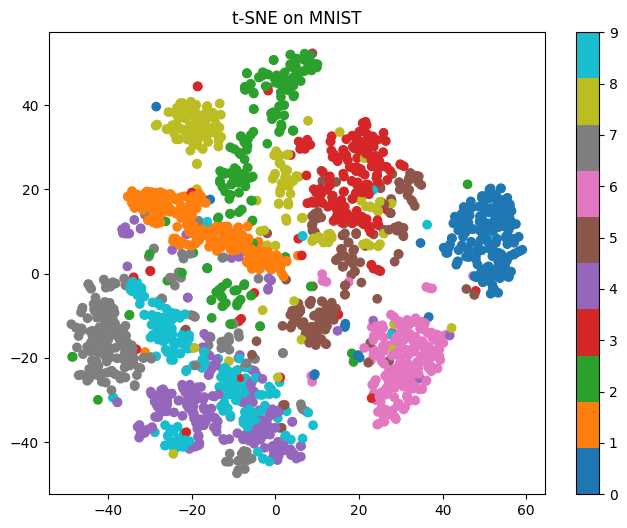

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(X_digits_tsne[:,0], X_digits_tsne[:,1],
            c=y_digits_small, cmap='tab10')
plt.colorbar()
plt.title("t-SNE on MNIST")
plt.show()

In [40]:
tsne_faces = TSNE(n_components=2, random_state=42)
X_faces_tsne = tsne_faces.fit_transform(X_faces_small)

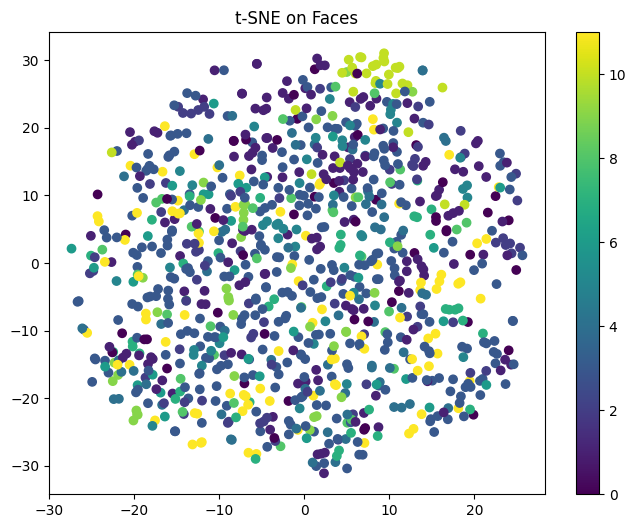

In [41]:
plt.figure(figsize=(8,6))
plt.scatter(X_faces_tsne[:,0], X_faces_tsne[:,1],
            c=y_faces_small, cmap='viridis')
plt.colorbar()
plt.title("t-SNE on Faces")
plt.show()

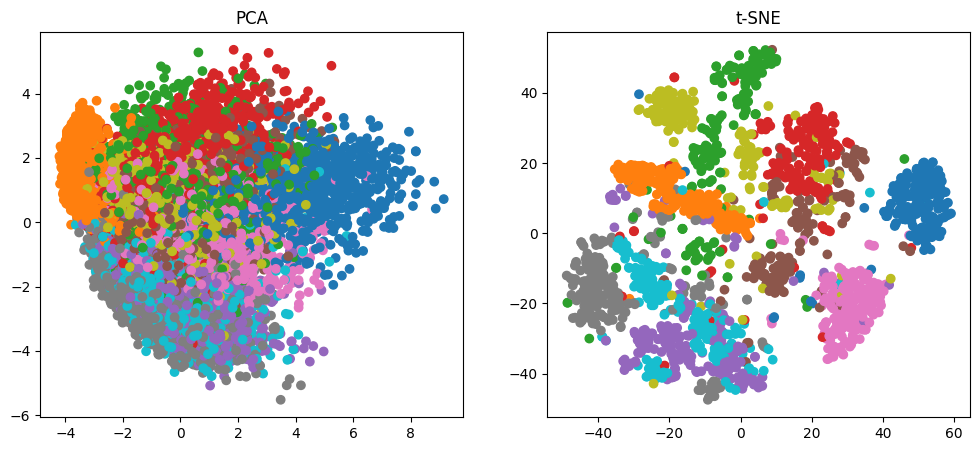

In [42]:
plt.figure(figsize=(12,5))

# PCA
plt.subplot(1,2,1)
plt.scatter(X_digits_pca[:,0], X_digits_pca[:,1], c=y_digits, cmap='tab10')
plt.title("PCA")

# t-SNE
plt.subplot(1,2,2)
plt.scatter(X_digits_tsne[:,0], X_digits_tsne[:,1], c=y_digits_small, cmap='tab10')
plt.title("t-SNE")

plt.show()